# GCN for Blood-Brain Barrier Permeability Prediction

This notebook implements a Graph Convolutional Network (GCN) using **PyTorch Geometric** to classify molecules as BBB permeable using the B3DB dataset.

**Index:**
1. Data analysis 
2. Molecular graph construction (atom + bond features)  
3. PyTorch Geometric dataset creation  
4. Configurable GCN model (depth, hidden dim, readout pooling)  
5. Hyperparameter tuning via **WandB Sweeps**  
6. Model evaluation & metrics  
7. Interpretability – GNNExplainer & saliency maps  
8. PCA visualisation of learned graph embeddings  


## 1. Importing Libraries

In [1]:
# Install dependencies
# !pip install torch torch-geometric rdkit-pypi wandb scikit-learn matplotlib seaborn pandas numpy


In [12]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

from torch_geometric.data import Data, dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GCNConv, GINConv, global_mean_pool, global_max_pool, global_add_pool
)
from torch_geometric.explain import Explainer, GNNExplainer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve
)

import wandb

import time

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = os.path.join("..", "data", "B3DB_classification.tsv")
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")


Device: cuda
PyTorch version: 2.7.1+cu118


## 2. Data Analysis

In [3]:
df = pd.read_csv(DATA_PATH, sep="\t")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()


Dataset shape: (7807, 12)

Columns: ['NO.', 'compound_name', 'IUPAC_name', 'SMILES', 'CID', 'logBB', 'BBB+/BBB-', 'Inchi', 'threshold', 'reference', 'group', 'comments']


,NO.,compound_name,IUPAC_name,SMILES,CID,logBB,BBB+/BBB-,Inchi,threshold,reference,group,comments
0,1,sulphasalazine,2-hydroxy-5-[[4-(pyridin-2-ylsulfamoyl)phenyl]...,O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O,5339.0,-2.69,BBB-,InChI=1S/C18H14N4O5S/c23-16-9-6-13(11-15(16)18...,NaN,R2|R2|R25|R46|,A,NaN
1,2,moxalactam,7-[[2-carboxy-2-(4-hydroxyphenyl)acetyl]amino]...,COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...,3889.0,-2.52,BBB-,InChI=1S/C20H20N6O9S/c1-25-19(22-23-24-25)36-8...,NaN,R25|,A,NaN
2,3,clioquinol,5-chloro-7-iodoquinolin-8-ol,Oc1c(I)cc(Cl)c2cccnc12,2788.0,-2.40,BBB-,InChI=1S/C9H5ClINO/c10-6-4-7(11)9(13)8-5(6)2-1...,NaN,R18|R26|R27|,A,NaN
3,4,bbcpd11 (cimetidine analog) (y-g13),2-[2-[(3-bromopyridin-2-yl)methylsulfanyl]ethy...,CCNC(=NCCSCc1ncccc1Br)NC#N,14022517.0,-2.15,BBB-,InChI=1S/C12H16BrN5S/c1-2-15-12(18-9-14)17-6-7...,NaN,R2|R2|R8|R40|R2|R2|R2|R2|R18|R21|R25|R25|R26|R...,A,NaN
4,5,schembl614298,"(2s,3s,4s,5r)-6-[[(4r,4ar,7s,7ar,12bs)-7-hydro...",CN1CC[C@]23c4c5ccc(OC6O[C@H](C(=O)O)[C@@H](O)[...,18595497.0,-2.15,BBB-,InChI=1S/C23H27NO9/c1-24-7-6-23-10-3-4-12(25)2...,NaN,R25|,A,NaN


Clean dataset size: 7807

Class distribution:
BBB+/BBB-
BBB+    4956
BBB-    2851
Name: count, dtype: int64


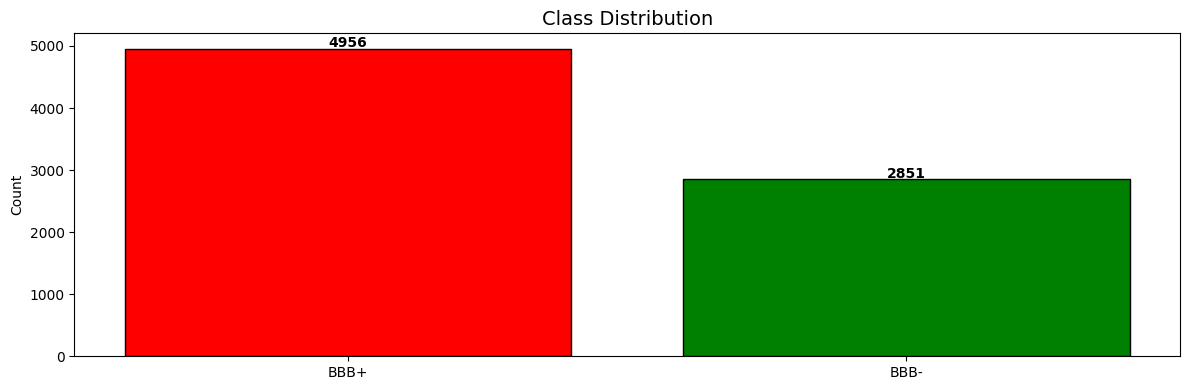

In [4]:
# Keep relevant columns
df = df[["SMILES", "BBB+/BBB-", "logBB", "compound_name"]].dropna(subset=["SMILES", "BBB+/BBB-"])
df = df[df["BBB+/BBB-"].isin(["BBB+", "BBB-"])].reset_index(drop=True)

# Binary label: 1 = BBB+, 0 = BBB-
df["label"] = (df["BBB+/BBB-"] == "BBB+").astype(int)

print(f"Clean dataset size: {len(df)}")
print(f"\nClass distribution:")
print(df["BBB+/BBB-"].value_counts())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

counts = df["BBB+/BBB-"].value_counts()
axes.bar(counts.index, counts.values, color=["red", "green"], edgecolor="black")
axes.set_title("Class Distribution", fontsize=14)
axes.set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes.text(i, v + 20, str(v), ha="center", fontweight="bold")


plt.tight_layout()
plt.savefig(os.path.join("..", "figures/gcn/", "gcn_eda.png"), dpi=150, bbox_inches="tight")
plt.show()


## 3. Molecular Feature Engineering

### Atom features
| Feature | Description |
|---|---|
| Atomic number | Element identity (one-ho) |
| Degree | Number of heavy-atom bonds |
| Formal charge | Ionic charge |
| Num H | Implicit + explicit H |
| Radical electrons | Unpaired electrons |
| Hybridisation | sp/sp2/sp3/sp3d/sp3d2 (one-hot) |
| Aromaticity | Boolean |
| Ring membership | Boolean |

### Bond features (optional sweep dimension)
| Feature | Description |
|---|---|
| Bond type | Single/Double/Triple/Aromatic (one-hot) |
| Conjugation | Boolean |
| Ring member | Boolean |
| Stereo | 6-class one-hot |


In [5]:
from rdkit.Chem.rdchem import HybridizationType, BondType, BondStereo

atom_nums = set()
for smi in df["SMILES"].dropna().unique():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    for a in mol.GetAtoms():
        atom_nums.add(a.GetAtomicNum())
print(f"Unique atomic numbers in dataset: {sorted(atom_nums)}")
print(f"Total unique atom types: {len(atom_nums)}")

ATOM_LIST = sorted(atom_nums)

HYBRIDISATION_LIST = [
    HybridizationType.SP,
    HybridizationType.SP2,
    HybridizationType.SP3,
    HybridizationType.SP3D,
    HybridizationType.SP3D2,
]
BOND_TYPE_LIST  = [BondType.SINGLE, BondType.DOUBLE, BondType.TRIPLE, BondType.AROMATIC]
BOND_STEREO_LIST = [
    BondStereo.STEREONONE,
    BondStereo.STEREOANY,
    BondStereo.STEREOZ,
    BondStereo.STEREOE,
    BondStereo.STEREOCIS,
    BondStereo.STEREOTRANS,
]

def one_hot(value, allowed):
    """Return a one-hot list; last position = 'other'."""
    enc = [0] * (len(allowed) + 1)
    if value in allowed:
        enc[allowed.index(value)] = 1
    else:
        enc[-1] = 1
    return enc


def atom_features(atom) -> list:
    return (
        one_hot(atom.GetAtomicNum(), ATOM_LIST)        # 17
        + [atom.GetDegree() / 10.0]                    # 1  (normalised)
        + [atom.GetFormalCharge() / 5.0]               # 1
        + [atom.GetTotalNumHs() / 4.0]                 # 1
        + [atom.GetNumRadicalElectrons() / 2.0]        # 1
        + one_hot(atom.GetHybridization(), HYBRIDISATION_LIST)   # 6
        + [int(atom.GetIsAromatic())]                  # 1
        + [int(atom.IsInRing())]                       # 1
    )  # total = 29


def bond_features(bond) -> list:
    return (
        one_hot(bond.GetBondType(), BOND_TYPE_LIST)    # 5
        + [int(bond.GetIsConjugated())]                # 1
        + [int(bond.IsInRing())]                       # 1
        + one_hot(bond.GetStereo(), BOND_STEREO_LIST)  # 7
    )  # total = 5 + 1 + 1 + 7 = 14


ATOM_FEAT_DIM = len(atom_features(Chem.MolFromSmiles("C").GetAtomWithIdx(0)))
BOND_FEAT_DIM = len(bond_features(Chem.MolFromSmiles("CC").GetBondWithIdx(0)))
print(f"Atom feature dimension : {ATOM_FEAT_DIM}")
print(f"Bond feature dimension : {BOND_FEAT_DIM}")


Unique atomic numbers in dataset: [3, 5, 6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 35, 36, 53, 54]
Total unique atom types: 16
Atom feature dimension : 29
Bond feature dimension : 14


## 4. PyTorch Geometric Dataset

In [6]:
def smiles_to_graph(smiles: str, label: int, use_bond_features: bool = True) -> Data | None:
    """Convert a SMILES string to a PyG Data object."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Node features
    x = torch.tensor(
        [atom_features(a) for a in mol.GetAtoms()],
        dtype=torch.float
    )  # [num_atoms, ATOM_FEAT_DIM]

    # Edge index (undirected , hence add both directions)
    edge_index, edge_attr_list = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond) if use_bond_features else []
        edge_index += [[i, j], [j, i]]
        edge_attr_list += [bf, bf]

    
    edge_index_t = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    if use_bond_features:
        edge_attr_t = torch.tensor(edge_attr_list, dtype=torch.float)
    else:
        edge_attr_t = None

    data = Data(
        x=x,
        edge_index=edge_index_t,
        edge_attr=edge_attr_t,
        y=torch.tensor([label], dtype=torch.long),
        smiles=smiles,
    )
    return data


def build_dataset(dataframe: pd.DataFrame, use_bond_features: bool = True):
    """Convert the dataframe to a list of PyG Data objects."""
    graphs, skipped = [], 0
    for _, row in dataframe.iterrows():
        g = smiles_to_graph(row["SMILES"], row["label"], use_bond_features)
        if g is not None:
            graphs.append(g)
        else:
            skipped += 1
    print(f"Converted {len(graphs)} molecules; skipped {skipped} invalid SMILES.")
    return graphs


# Build full dataset (bond features ON for now)
all_graphs = build_dataset(df, use_bond_features=True)
print(f"\nSample graph: {all_graphs[0]}")


Converted 7805 molecules; skipped 2 invalid SMILES.

Sample graph: Data(x=[28, 29], edge_index=[2, 60], edge_attr=[60, 14], y=[1], smiles='O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O')


In [7]:
# Train / Val / Test split (64-16-20, stratified)
labels = [g.y.item() for g in all_graphs]

train_graphs, test_graphs, _, y_test = train_test_split(
    all_graphs, labels, test_size=0.2, random_state=SEED, stratify=labels
)
train_graphs, val_graphs, _, _ = train_test_split(
    train_graphs,
    [g.y.item() for g in train_graphs],
    test_size=0.2,
    random_state=SEED,
    stratify=[g.y.item() for g in train_graphs],
)

print(f"Train : {len(train_graphs)}")
print(f"Val   : {len(val_graphs)}")
print(f"Test  : {len(test_graphs)}")

def make_loaders(train, val, test, batch_size=32):
    return (
        DataLoader(train, batch_size=batch_size, shuffle=True),
        DataLoader(val,   batch_size=batch_size, shuffle=False),
        DataLoader(test,  batch_size=batch_size, shuffle=False),
    )

train_loader, val_loader, test_loader = make_loaders(
    train_graphs, val_graphs, test_graphs
)


Train : 4995
Val   : 1249
Test  : 1561


## 5. GCN Model Architecture

In [8]:
POOLING_FNS = {
    "mean": global_mean_pool,
    "max":  global_max_pool,
    "sum":  global_add_pool,
}


class GCN(nn.Module):
    """
    GCN Class

    Parameters
    ----------
    in_channels   : input node-feature dimension
    hidden_dim    : dimension of hidden layers
    num_layers    : number of GCN conv layers (depth)
    dropout       : dropout probability applied after each conv
    readout       : graph-level pooling strategy – 'mean' | 'max' | 'sum'
    num_classes   : output classes (2 for binary)
    """

    def __init__(
        self,
        in_channels: int,
        hidden_dim: int = 128,
        num_layers: int = 3,
        dropout: float = 0.3,
        readout: str = "mean",
        num_classes: int = 2,
    ):
        super().__init__()
        self.dropout  = dropout
        self.readout  = POOLING_FNS[readout]
        self.convs    = nn.ModuleList()
        self.bns      = nn.ModuleList()

        # Input to first hidden layer
        self.convs.append(GCNConv(in_channels, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Subsequent hidden layers
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Classifier MLP
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x, edge_index, batch):
        # Message passing
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Readout - gives final graph embedding
        graph_emb = self.readout(x, batch)   # [batch_size, hidden_dim]

        # Classification
        out = self.classifier(graph_emb)     # [batch_size, num_classes]
        return out, graph_emb

    def embed(self, x, edge_index, batch):
        """Return graph-level embeddings (no classification head)."""
        _, emb = self.forward(x, edge_index, batch)
        return emb


# Testing
_model = GCN(in_channels=ATOM_FEAT_DIM).to(DEVICE)
print(_model)
_batch = next(iter(train_loader)).to(DEVICE)
_logits, _emb = _model(_batch.x, _batch.edge_index, _batch.batch)
print(f"\nLogits shape  : {_logits.shape}")
print(f"Embedding shape: {_emb.shape}")


GCN(
  (convs): ModuleList(
    (0): GCNConv(29, 128)
    (1-2): 2 x GCNConv(128, 128)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

Logits shape  : torch.Size([32, 2])
Embedding shape: torch.Size([32, 128])


## 6. Training & Evaluation Utilities

In [9]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_probs, all_labels = 0.0, [], [], []
    for batch in loader:
        batch = batch.to(device)
        logits, _ = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y)
        total_loss += loss.item() * batch.num_graphs
        probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(batch.y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc  = accuracy_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs)
    f1   = f1_score(all_labels, all_preds)
    return avg_loss, acc, auc, f1, all_labels, all_probs, all_preds


def plot_metrics(train_losses, val_losses, val_accs, val_aucs, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    epochs = range(1, len(train_losses) + 1)

    axes[0].plot(epochs, train_losses, label="Train loss", color="blue")
    axes[0].plot(epochs, val_losses,   label="Val loss",   color="red")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, val_accs, color="#2ecc71")
    axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1)

    axes[2].plot(epochs, val_aucs, color="#9b59b6")
    axes[2].set_title("Validation AUC-ROC"); axes[2].set_xlabel("Epoch")
    axes[2].set_ylim(0, 1)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


## 7. Hyperparameter Tuning with WandB Sweeps

We sweep over:

| Parameter | Values |
|---|---|
| `num_layers` | 2, 3, 4 |
| `hidden_dim` | 64, 128, 256 |
| `readout` | mean, max, sum |
| `learning_rate` | log-uniform [1e-4, 1e-2] |
| `dropout` | 0.3, 0.5 |
| `use_bond_features` | True, False |
| `batch_size` | 32, 64 |


In [ ]:
SWEEP_CONFIG = {
    "method": "bayes",          # Bayesian optimisation
    "metric": {"name": "val_auc", "goal": "maximize"},
    "parameters": {
        "num_layers":        {"values": [2, 3, 4]},
        "hidden_dim":        {"values": [64, 128, 256]},
        "readout":           {"values": ["mean", "max", "sum"]},
        "learning_rate":     {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-2},
        "dropout":           {"values": [ 0.3, 0.5]},
        "use_bond_features": {"values": [True, False]},
        "batch_size":        {"values": [32, 64]},
        "epochs":            {"value": 50},
        "weight_decay":      {"values": [1e-4, 1e-5]},
    },
}

In [13]:
def sweep_train():
    """One sweep run: called by wandb.agent."""
    run = wandb.init()
    cfg = wandb.config

    graphs = build_dataset(df, use_bond_features=cfg.use_bond_features)
    labels_all = [g.y.item() for g in graphs]

    tr, te, _, yte = train_test_split(
        graphs, labels_all,
        test_size=0.2, random_state=SEED, stratify=labels_all
    )
    tr, va, _, _ = train_test_split(
        tr, [g.y.item() for g in tr],
        test_size=0.2, random_state=SEED,
        stratify=[g.y.item() for g in tr]
    )

    trl, val, tel = make_loaders(tr, va, te, batch_size=cfg.batch_size)

    model = GCN(
        in_channels=ATOM_FEAT_DIM,
        hidden_dim=cfg.hidden_dim,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
        readout=cfg.readout,
    ).to(DEVICE)

    # Class-weighted loss to handle imbalance
    pos_weight = (labels_all.count(0) / max(labels_all.count(1), 1))
    weights = torch.tensor([1.0, pos_weight], dtype=torch.float).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = Adam(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay
    )
    scheduler = ReduceLROnPlateau(optimizer, "max", patience=5, factor=0.5)

    best_val_auc = 0.0
    start_time = time.time()
    for epoch in range(1, cfg.epochs + 1):
        train_loss = train_epoch(model, trl, optimizer, criterion, DEVICE)
        val_loss, val_acc, val_auc, val_f1, *_ = evaluate(model, val, criterion, DEVICE)
        scheduler.step(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), "../figures/gcn/best_gcn_sweep.pt")

        wandb.log({
            "epoch":      epoch,
            "train_loss": train_loss,
            "val_loss":   val_loss,
            "val_acc":    val_acc,
            "val_auc":    val_auc,
            "val_f1":     val_f1,
            "lr":         optimizer.param_groups[0]["lr"],
        })
    print(f"Time taken: {time.time() - start_time:.2f} seconds")


    run.finish()
    return best_val_auc


In [14]:
WANDB_PROJECT = "bbb-gcn-1"
COUNT = 20           # number of sweep runs

sweep_id = wandb.sweep(SWEEP_CONFIG, project=WANDB_PROJECT)
print(f"Sweep ID: {sweep_id}")
wandb.agent(sweep_id, function=sweep_train, count=COUNT, project=WANDB_PROJECT)


Create sweep with ID: wmm6csso
Sweep URL: https://wandb.ai/bhuvan-kapur1-iiith/bbb-gcn-1/sweeps/wmm6csso
Sweep ID: wmm6csso


wandb: Agent Starting Run: t52hgxka with config:
wandb: 	batch_size: 64
wandb: 	dropout: 0.5
wandb: 	epochs: 50
wandb: 	hidden_dim: 128
wandb: 	learning_rate: 0.004479014999886262
wandb: 	num_layers: 3
wandb: 	readout: max
wandb: 	use_bond_features: False
wandb: 	weight_decay: 0.0001
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Converted 7805 molecules; skipped 2 invalid SMILES.


/home2/bhuvan.kapur/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home2/bhuvan.kapur/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home2/bhuvan.kapur/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home2/bhuvan.kapur/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home2/bhuvan.kapur/.local/lib/python3.10/site-packages/torch_ge

Time taken: 47.31 seconds


...

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂▂▁▁▁▁▁▁▂▁
val_acc,▁▃▄▃▄▄▅▅▅▄▆▅▅▆▆▇▆▆▆▇▇▇▆▆▆▇▇▆▇▇▇▇▇▇█▇█▇█▇
val_auc,▁▃▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
val_f1,▁▃▄▄▅▅▅▅▅▆▅▅▇▆▆▇▆▆▆▇▇▆▆▇▆▇▆█▇▇▇▇▇██▇█▇█▆
val_loss,█▆▅▅▅▄▄▄▅▄▃▃▃▃▃▂▂▂▃▂▂▂▂▂▁▂▂▂▁▂▁▁▂▁▁▁▁▁▂▁
epoch,50
lr,0.00036
train_loss,0.29169
val_acc,0.85268


wandb: Agent Starting Run: zr38l7px with config:
wandb: 	batch_size: 32
wandb: 	dropout: 0.5
wandb: 	epochs: 50
wandb: 	hidden_dim: 256
wandb: 	learning_rate: 0.0018618537660768323
wandb: 	num_layers: 4
wandb: 	readout: sum
wandb: 	use_bond_features: True
wandb: 	weight_decay: 0.0001


Converted 7805 molecules; skipped 2 invalid SMILES.


Traceback (most recent call last):
  File "/home2/bhuvan.kapur/.local/lib/python3.10/site-packages/wandb/agents/pyagent.py", line 297, in _run_job
    self._function()
  File "/tmp/ipykernel_1469224/2152410193.py", line 44, in sweep_train
    train_loss = train_epoch(model, trl, optimizer, criterion, DEVICE)
  File "/tmp/ipykernel_1469224/3998082414.py", line 7, in train_epoch
    logits, _ = model(batch.x, batch.edge_index, batch.batch)
  File "/home2/bhuvan.kapur/.local/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1751, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/home2/bhuvan.kapur/.local/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1762, in _call_impl
    return forward_call(*args, **kwargs)
  File "/tmp/ipykernel_1469224/256330943.py", line 57, in forward
    x = conv(x, edge_index)
  File "/home2/bhuvan.kapur/.local/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1751, in _wrapped_call_impl
    retur

epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▃▂▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▆▂▇▇▆▇▇▇▇▇█▇▇
val_auc,▁▂▆▄▆▅▄▆▇█▇██▇
val_f1,▁▇▁███▇▇▇▆██▇▇
val_loss,██▅▃▃▄▄▂▁▂▂▂▁▁
epoch,14
lr,0.00186
train_loss,0.48033
val_acc,0.81185


## Best Hyperparameters

From above sweep, we obtain best validation AUC with hyperparameters : 

num_layers=4

hidden_dim=256

readout="mean"

learning_rate=1e-3

dropout=0.3

use_bond_features=True

batch_size=64

epochs=100

weight_decay=1e-4

### 7b. Training Run with Best Hyperparameters

Converted 7805 molecules; skipped 2 invalid SMILES.
Epoch  10 | Train Loss 0.3735 | Val Loss 0.3732 | Val Acc 0.8221 | Val AUC 0.9102
Epoch  20 | Train Loss 0.3435 | Val Loss 0.3474 | Val Acc 0.8439 | Val AUC 0.9279
Epoch  30 | Train Loss 0.3246 | Val Loss 0.3265 | Val Acc 0.8675 | Val AUC 0.9351
Epoch  40 | Train Loss 0.3045 | Val Loss 0.3131 | Val Acc 0.8621 | Val AUC 0.9392
Epoch  50 | Train Loss 0.2943 | Val Loss 0.3055 | Val Acc 0.8584 | Val AUC 0.9423
Epoch  60 | Train Loss 0.2541 | Val Loss 0.3015 | Val Acc 0.8603 | Val AUC 0.9455
Epoch  70 | Train Loss 0.2327 | Val Loss 0.3215 | Val Acc 0.8684 | Val AUC 0.9447
Epoch  80 | Train Loss 0.2298 | Val Loss 0.3181 | Val Acc 0.8711 | Val AUC 0.9453
Epoch  90 | Train Loss 0.2182 | Val Loss 0.3189 | Val Acc 0.8684 | Val AUC 0.9468
Epoch 100 | Train Loss 0.2159 | Val Loss 0.3216 | Val Acc 0.8730 | Val AUC 0.9465

Best Validation AUC: 0.9481 (epoch 59)


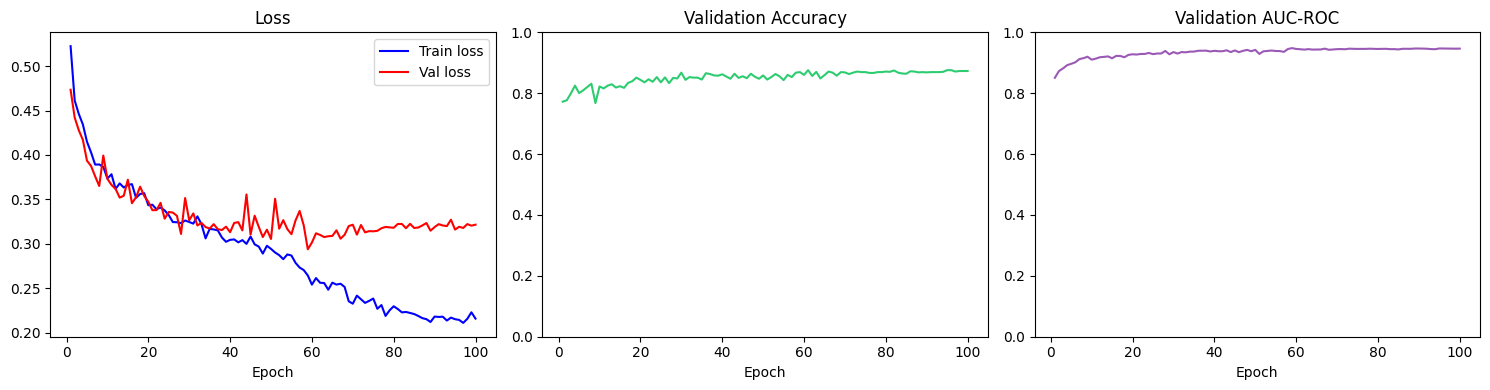

In [15]:
# Best hyperparameters
RUN_CFG = dict(
    num_layers=4,
    hidden_dim=256,
    readout="mean",
    learning_rate=1e-3,
    dropout=0.3,
    use_bond_features=True,
    batch_size=64,
    epochs=100,
    weight_decay=1e-4,
)

graphs_run = build_dataset(df, use_bond_features=RUN_CFG["use_bond_features"])
labels_run  = [g.y.item() for g in graphs_run]
tr_r, te_r, _, _ = train_test_split(graphs_run, labels_run, test_size=0.2,
                                     random_state=SEED, stratify=labels_run)
tr_r, va_r, _, _ = train_test_split(tr_r, [g.y.item() for g in tr_r],
                                     test_size=0.15/0.85, random_state=SEED,
                                     stratify=[g.y.item() for g in tr_r])
trl_r, val_r, tel_r = make_loaders(tr_r, va_r, te_r, batch_size=RUN_CFG["batch_size"])

# Model
model = GCN(
    in_channels=ATOM_FEAT_DIM,
    hidden_dim=RUN_CFG["hidden_dim"],
    num_layers=RUN_CFG["num_layers"],
    dropout=RUN_CFG["dropout"],
    readout=RUN_CFG["readout"],
).to(DEVICE)

pos_wt = labels_run.count(0) / max(labels_run.count(1), 1)
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, pos_wt], dtype=torch.float).to(DEVICE)
)
optimizer = Adam(model.parameters(), lr=RUN_CFG["learning_rate"],
                  weight_decay=RUN_CFG["weight_decay"])
scheduler = ReduceLROnPlateau(optimizer, "max", patience=8, factor=0.5)

# Training loop
train_losses, val_losses, val_accs, val_aucs = [], [], [], []
best_val_auc, best_epoch = 0.0, 0

for epoch in range(1, RUN_CFG["epochs"] + 1):
    tl = train_epoch(model, trl_r, optimizer, criterion, DEVICE)
    vl, va, vauc, vf1, *_ = evaluate(model, val_r, criterion, DEVICE)
    scheduler.step(vauc)

    train_losses.append(tl)
    val_losses.append(vl)
    val_accs.append(va)
    val_aucs.append(vauc)

    if vauc > best_val_auc:
        best_val_auc = vauc
        best_epoch   = epoch
        torch.save(model.state_dict(), os.path.join("..", "figures/gcn/", "best_gcn.pt"))

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss {tl:.4f} | "
              f"Val Loss {vl:.4f} | Val Acc {va:.4f} | Val AUC {vauc:.4f}")

print(f"\nBest Validation AUC: {best_val_auc:.4f} (epoch {best_epoch})")
plot_metrics(train_losses, val_losses, val_accs, val_aucs,
             save_path=os.path.join("..", "figures/gcn/", "gcn_training_curves.png"))


Test Accuracy : 0.8744
Test AUC-ROC  : 0.9440
Test F1-Score : 0.8995

Classification Report:
              precision    recall  f1-score   support

        BBB-       0.81      0.86      0.83       570
        BBB+       0.91      0.88      0.90       991

    accuracy                           0.87      1561
   macro avg       0.86      0.87      0.87      1561
weighted avg       0.88      0.87      0.88      1561



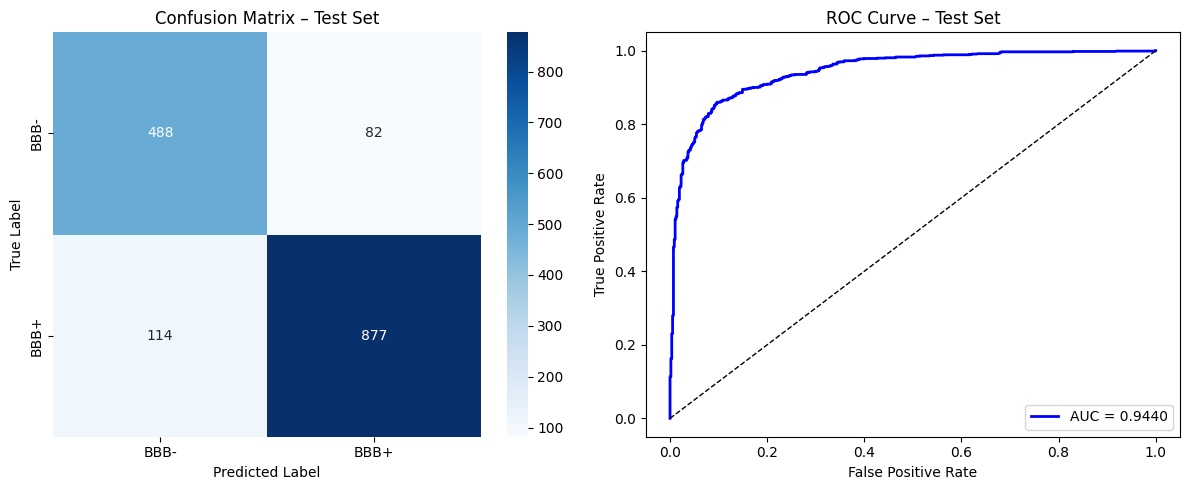

In [16]:
#  Loading best checkpoint and evaluate on held-out test set
model.load_state_dict(torch.load(os.path.join("..", "figures/gcn/", "best_gcn.pt"), map_location=DEVICE))
_, test_acc, test_auc, test_f1, y_true, y_probs, y_preds = evaluate(
    model, tel_r, criterion, DEVICE
)

print("=" * 50)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test AUC-ROC  : {test_auc:.4f}")
print(f"Test F1-Score : {test_f1:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_true, y_preds, target_names=["BBB-", "BBB+"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm_arr = confusion_matrix(y_true, y_preds)
sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["BBB-", "BBB+"], yticklabels=["BBB-", "BBB+"])
axes[0].set_title("Confusion Matrix – Test Set")
axes[0].set_ylabel("True Label"); axes[0].set_xlabel("Predicted Label")

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
axes[1].plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {test_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC Curve – Test Set")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join("..", "figures/gcn/", "gcn_test_evaluation.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## AUC-ROC achieved by best model on Test Set : 0.944

## 8. Interpretability – GNNExplainer

GNNExplainer learns a soft mask over edges and node features that maximally preserves the model's prediction for a given instance.  
We visualise the top-scoring atoms and bonds for representative BBB+ and BBB− molecules.


BBB+ molecules (GNNExplainer atom importance)



--- BBB+ sample 1: CCC(=O)O[C@]1(C(=O)COC(C)=O)CC[C@H]2[C@@H]3C[C@H]( ---


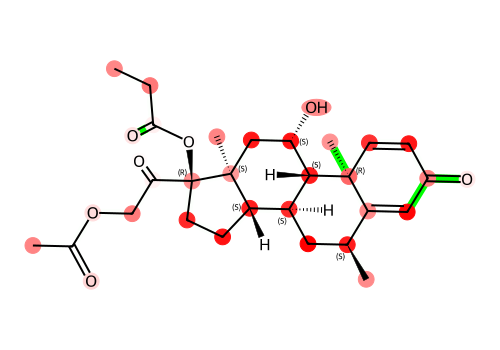


--- BBB+ sample 2: CN1[C@H]2CC[C@H]1CC(NC(=O)c1cn(C3CCCCC3)c3ccccc3c1 ---


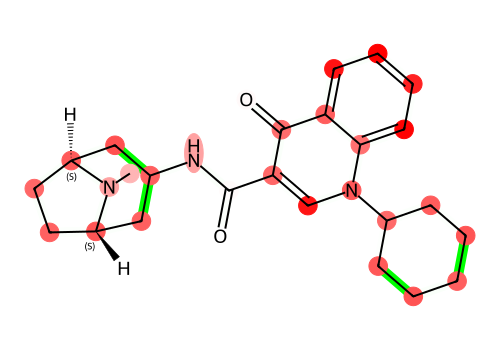


--- BBB+ sample 3: CN1[C@H](C[C@@H](O)c2ccccc2)CCC[C@@H]1CC(=O)c1cccc ---


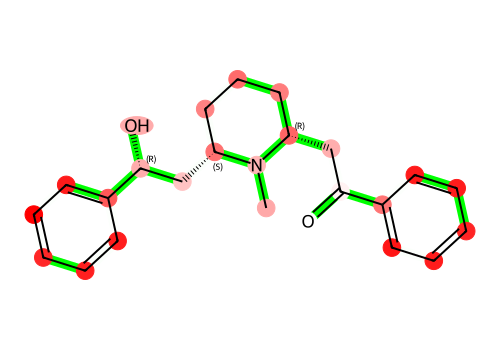


BBB- molecules (GNNExplainer atom importance)

--- BBB- sample 1: COC1=CC(=O)CC(C)C12Oc1c(Cl)c(OC)cc(OC)c1C2=O ---


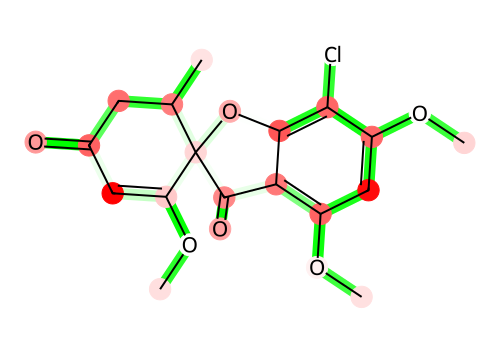


--- BBB- sample 2: C=CC[C@@H]1C=C(C)C[C@H](C)C[C@H](OC)[C@H]2O[C@@](O ---


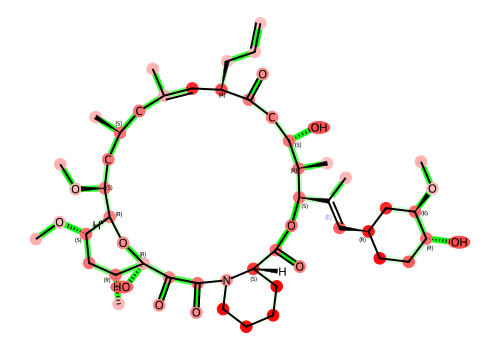


--- BBB- sample 3: CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)CNC(=N)c3ccn ---


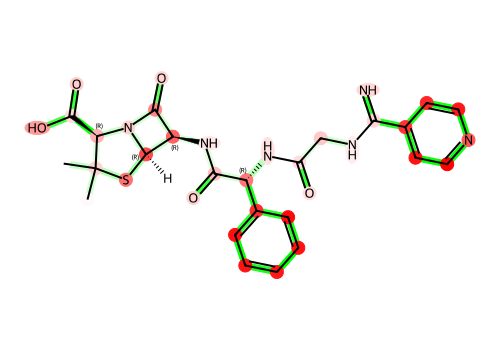

In [32]:
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display
import io

class GCNForExplainer(nn.Module):
    """wrapper exposing a single-tensor forward for PyG Explainer."""
    def __init__(self, gcn_model):
        super().__init__()
        self.model = gcn_model

    def forward(self, x, edge_index, batch=None):
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        logits, _ = self.model(x, edge_index, batch)
        return logits


model.eval()
wrapped = GCNForExplainer(model).to(DEVICE)

explainer = Explainer(
    model=wrapped,
    algorithm=GNNExplainer(epochs=200),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(
        mode="multiclass_classification",
        task_level="graph",
        return_type="raw",
    ),
)


def explain_molecule(graph_data, title=""):
    """Run GNNExplainer on one graph and draw coloured atom importance."""
    data = graph_data.to(DEVICE)
    explanation = explainer(
        x=data.x,
        edge_index=data.edge_index,
        batch=torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE),
        index=0,
    )

    # Node importance = mean absolute value of node feature mask
    node_mask  = explanation.node_mask          # [N, feat_dim]
    node_imp   = node_mask.abs().mean(dim=-1).cpu().detach().numpy()

    # Normalise to [0, 1]
    if node_imp.max() > node_imp.min():
        node_imp = (node_imp - node_imp.min()) / (node_imp.max() - node_imp.min())

    mol = Chem.MolFromSmiles(data.smiles)
    if mol is None:
        return

    # Colour atoms by importance (white → red)
    atom_colours = {}
    for i, imp in enumerate(node_imp):
        atom_colours[i] = (1.0, 1.0 - imp, 1.0 - imp)   # (R, G, B)
        r = float(1.0)
        g = float(1.0 - float(imp))
        b = float(1.0 - float(imp))
        atom_colours[int(i)] = (r, g, b)

    # Edge mask → bond highlights
    edge_mask  = explanation.edge_mask.cpu().detach().numpy()
    ei         = data.edge_index.cpu().numpy()
    bond_imp   = {}
    for k in range(ei.shape[1]):
        u, v = int(ei[0, k]), int(ei[1, k])
        bond = mol.GetBondBetweenAtoms(u, v)
        if bond is not None:
            bid = bond.GetIdx()
            bond_imp[bid] = max(bond_imp.get(bid, 0.0), float(edge_mask[k]))

    if bond_imp and max(bond_imp.values()) > 0:
        mn, mx = min(bond_imp.values()), max(bond_imp.values())
        bond_colours = { # white to green
            bid: (1.0 - (v - mn) / (mx - mn + 1e-8), 1.0, 1.0 - (v - mn) / (mx - mn + 1e-8))
            for bid, v in bond_imp.items()
        }
    else:
        bond_colours = {}

    drawer = rdMolDraw2D.MolDraw2DSVG(500, 350)
    drawer.drawOptions().addStereoAnnotation = True
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=list(atom_colours.keys()),
        highlightAtomColors=atom_colours,
        highlightBonds=list(bond_colours.keys()),
        highlightBondColors=bond_colours,
    )
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()

    from IPython.display import SVG
    print(f"\n--- {title} ---")
    display(SVG(svg))
    return node_imp, bond_imp


# Pick 3 BBB+ and 3 BBB- examples from the test set
import random
bbb_pos_samples = [g for g in te_r if g.y.item() == 1]
random.shuffle(bbb_pos_samples)
bbb_pos_samples = bbb_pos_samples[:3]
bbb_neg_samples = [g for g in te_r if g.y.item() == 0]
random.shuffle(bbb_neg_samples)
bbb_neg_samples = bbb_neg_samples[:3]

print("BBB+ molecules (GNNExplainer atom importance)")
for i, g in enumerate(bbb_pos_samples):
    explain_molecule(g, title=f"BBB+ sample {i+1}: {g.smiles[:50]}")

print("\nBBB- molecules (GNNExplainer atom importance)")
for i, g in enumerate(bbb_neg_samples):
    explain_molecule(g, title=f"BBB- sample {i+1}: {g.smiles[:50]}")


## 9. Interpretability – Gradient Saliency Maps

Saliency (gradient) computes $\frac{\partial \hat{y}_c}{\partial \mathbf{x}_i}$ for each atom $i$.  
A large magnitude indicates that atom $i$'s features strongly influence the model's class-$c$ prediction.  
We aggregate across feature dimensions to obtain a per-atom importance score and overlay it on the molecule.


════════════════════════════════════════════════════════════
Gradient Saliency Maps – BBB+ molecules
════════════════════════════════════════════════════════════

--- BBB+ sample 1 ---


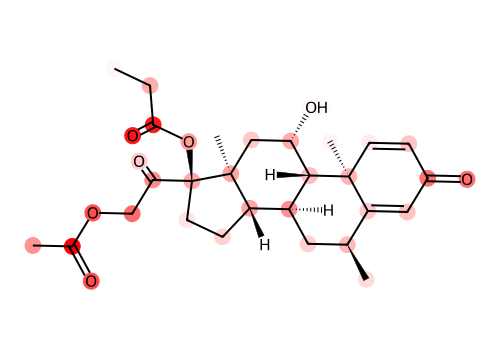

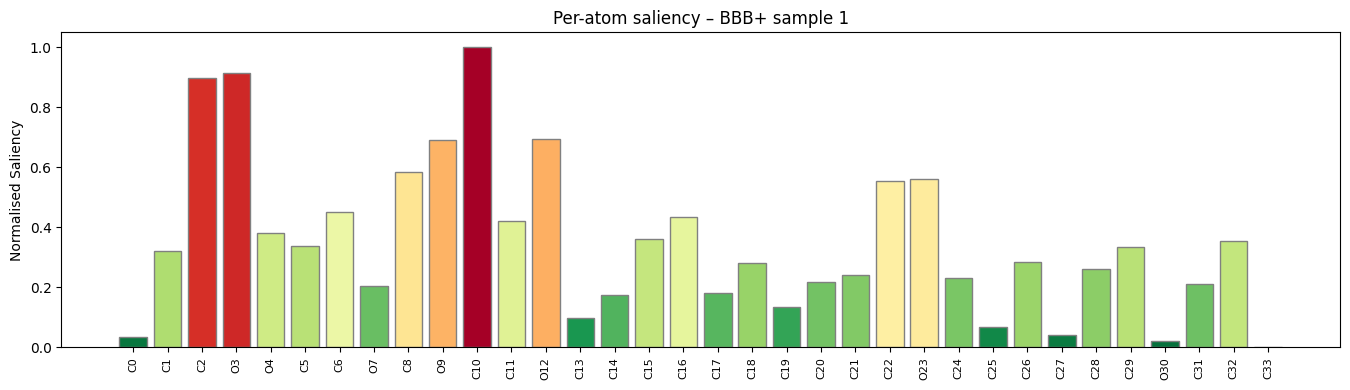


--- BBB+ sample 2 ---


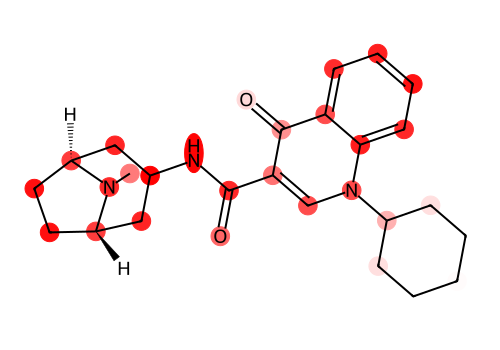

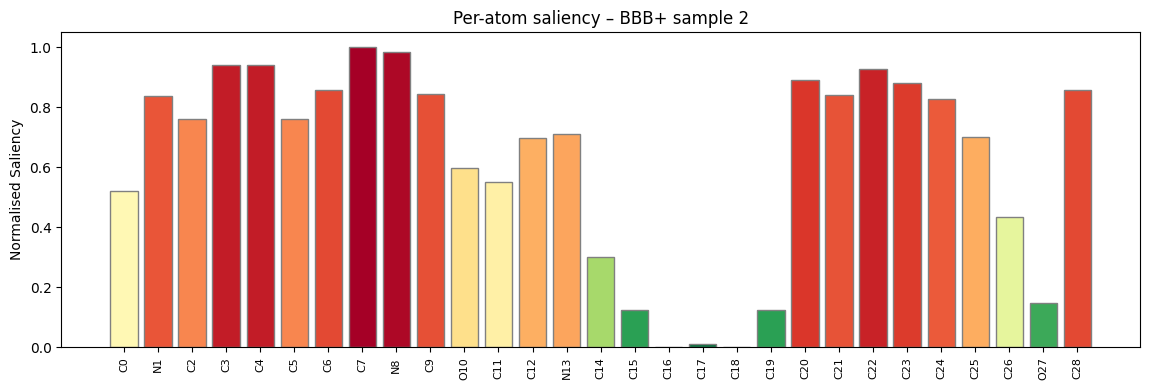


--- BBB+ sample 3 ---


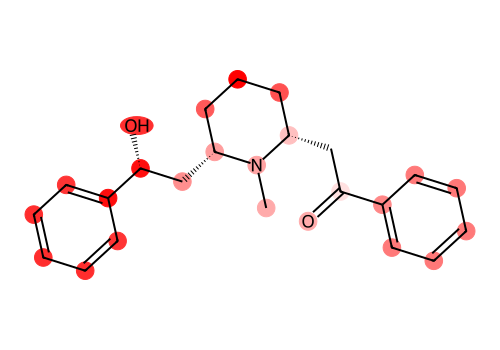

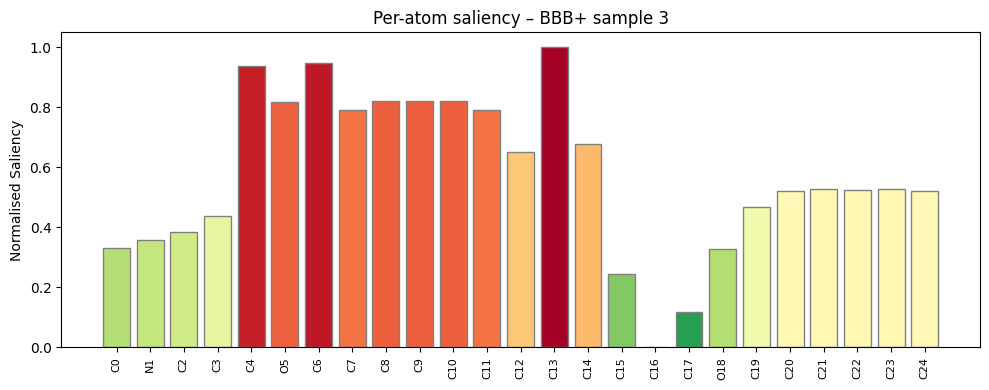

════════════════════════════════════════════════════════════
Gradient Saliency Maps – BBB- molecules
════════════════════════════════════════════════════════════

--- BBB- sample 1 ---


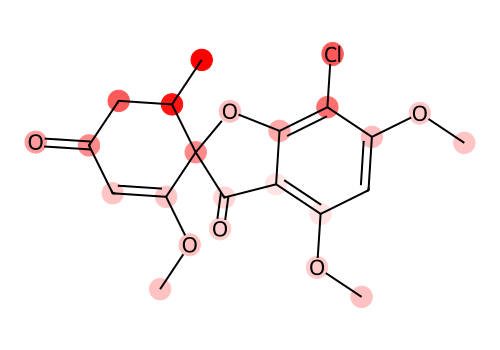

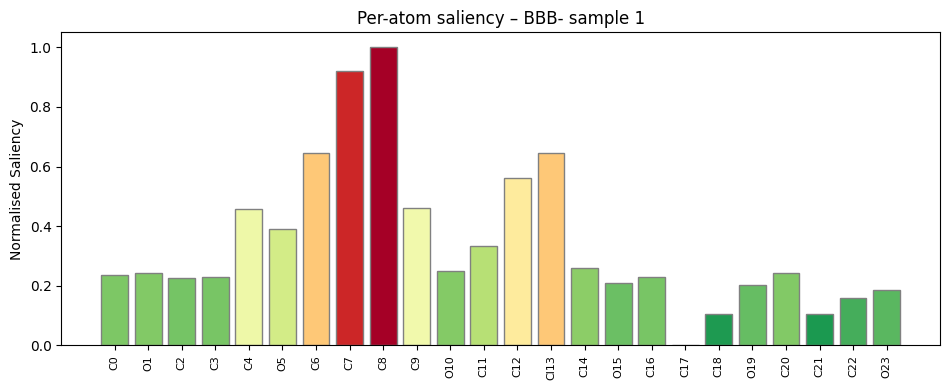


--- BBB- sample 2 ---


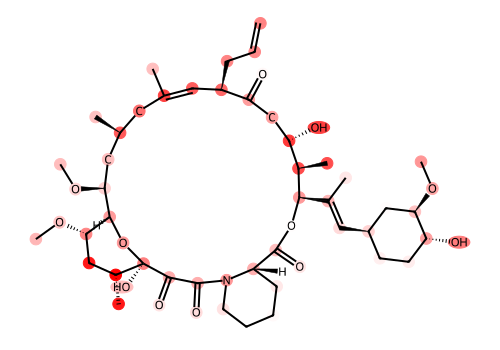

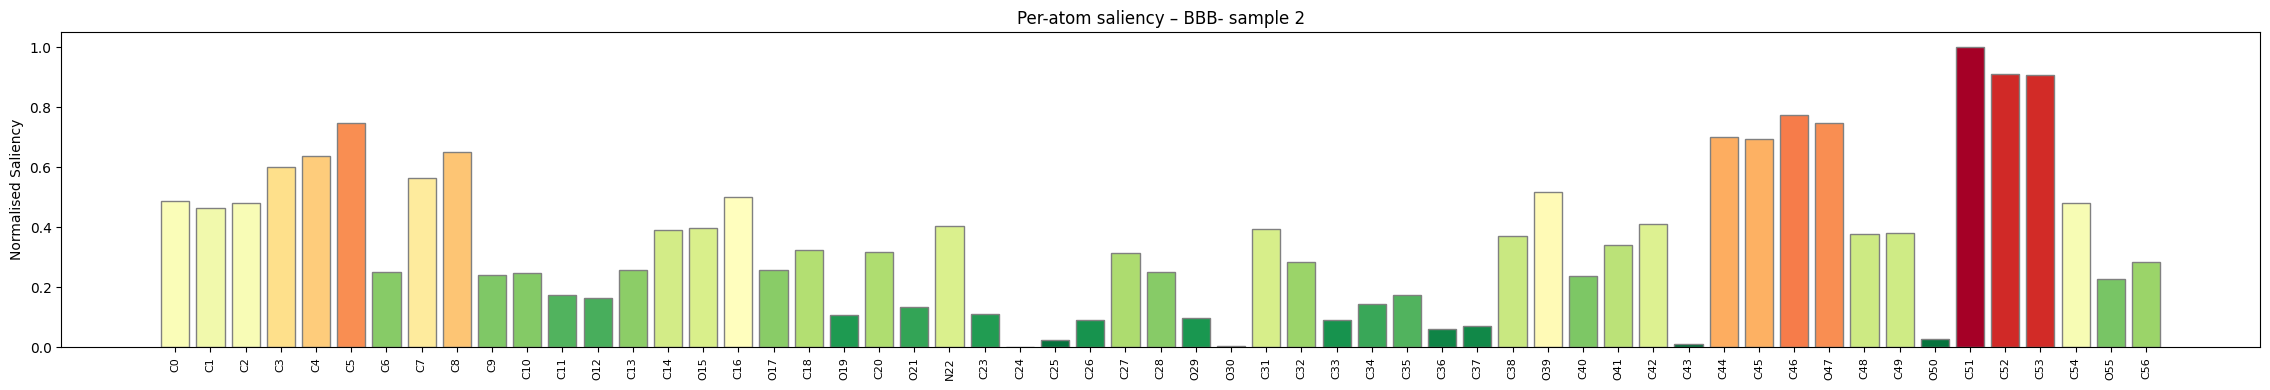


--- BBB- sample 3 ---


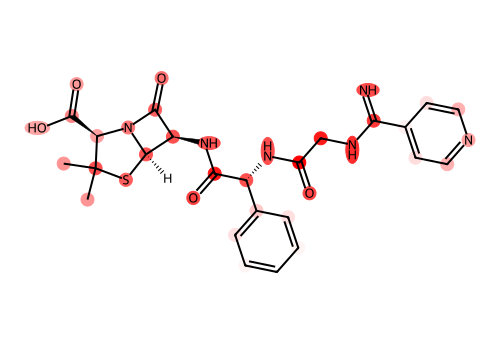

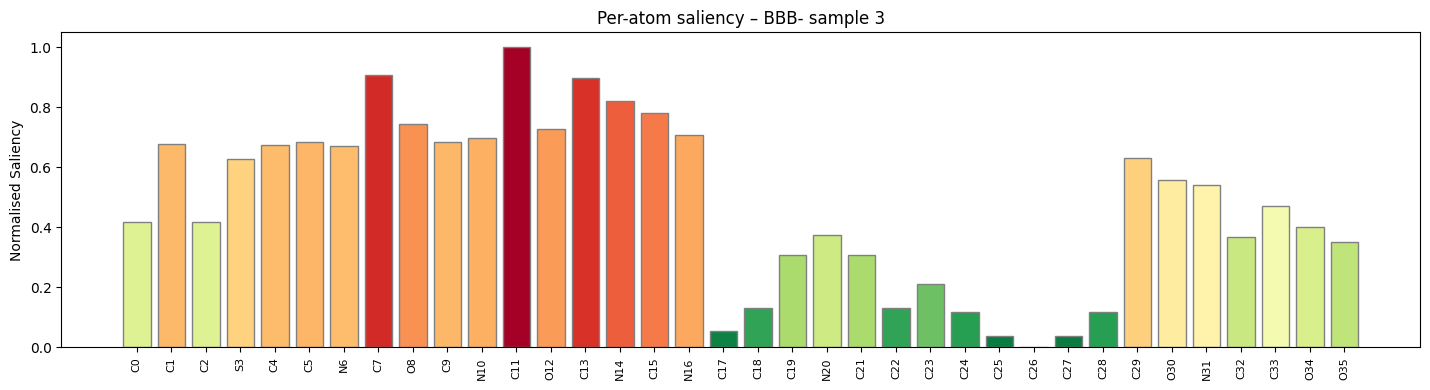

In [33]:
def gradient_saliency(graph_data, target_class: int = 1):
    """
    Compute gradient saliency w.r.t. node features.

    Returns
    -------
    node_saliency : np.ndarray of shape [num_atoms]
    """
    data  = graph_data.to(DEVICE)
    x     = data.x.clone().requires_grad_(True)
    batch = torch.zeros(x.size(0), dtype=torch.long, device=DEVICE)

    model.eval()
    logits, _ = model(x, data.edge_index, batch)
    score = logits[0, target_class]
    score.backward()

    saliency = x.grad.abs().mean(dim=-1).cpu().detach().numpy()
    if saliency.max() > saliency.min():
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())
    return saliency


def draw_saliency(graph_data, saliency, title=""):
    """Render molecule with atom colours proportional to saliency."""
    from IPython.display import SVG
    mol = Chem.MolFromSmiles(graph_data.smiles)
    if mol is None:
        return

    atom_colours = {i: (float(1.0), float(1.0 - s), float(1.0 - s)) for i, s in enumerate(saliency)}

    drawer = rdMolDraw2D.MolDraw2DSVG(500, 350)
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=list(atom_colours.keys()),
        highlightAtomColors=atom_colours,
    )
    drawer.FinishDrawing()
    print(f"\n--- {title} ---")
    display(SVG(drawer.GetDrawingText()))


def plot_saliency_bar(graph_data, saliency, title=""):
    """Bar chart of per-atom saliency scores."""
    mol    = Chem.MolFromSmiles(graph_data.smiles)
    labels = [f"{mol.GetAtomWithIdx(i).GetSymbol()}{i}" for i in range(mol.GetNumAtoms())]
    plt.figure(figsize=(max(8, len(labels) * 0.4), 4))
    colors = cm.RdYlGn_r(saliency)
    plt.bar(labels, saliency, color=colors, edgecolor="grey")
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Normalised Saliency")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Saliency for the same BBB+ / BBB− samples
print("═" * 60)
print("Gradient Saliency Maps – BBB+ molecules")
print("═" * 60)
for i, g in enumerate(bbb_pos_samples):
    sal = gradient_saliency(g, target_class=1)
    draw_saliency(g, sal, title=f"BBB+ sample {i+1}")
    plot_saliency_bar(g, sal, title=f"Per-atom saliency – BBB+ sample {i+1}")

print("═" * 60)
print("Gradient Saliency Maps – BBB- molecules")
print("═" * 60)
for i, g in enumerate(bbb_neg_samples):
    sal = gradient_saliency(g, target_class=0)
    draw_saliency(g, sal, title=f"BBB- sample {i+1}")
    plot_saliency_bar(g, sal, title=f"Per-atom saliency – BBB- sample {i+1}")


## 10. PCA Visualisation of Graph Embeddings

We extract the graph-level embedding (output of the readout layer) for every molecule in the test set and project it to 2D with PCA.  
Points are coloured by true class; correctly / incorrectly classified molecules are marked with different markers.

PCA explained variance: PC1 = 20.33%, PC2 = 16.66%


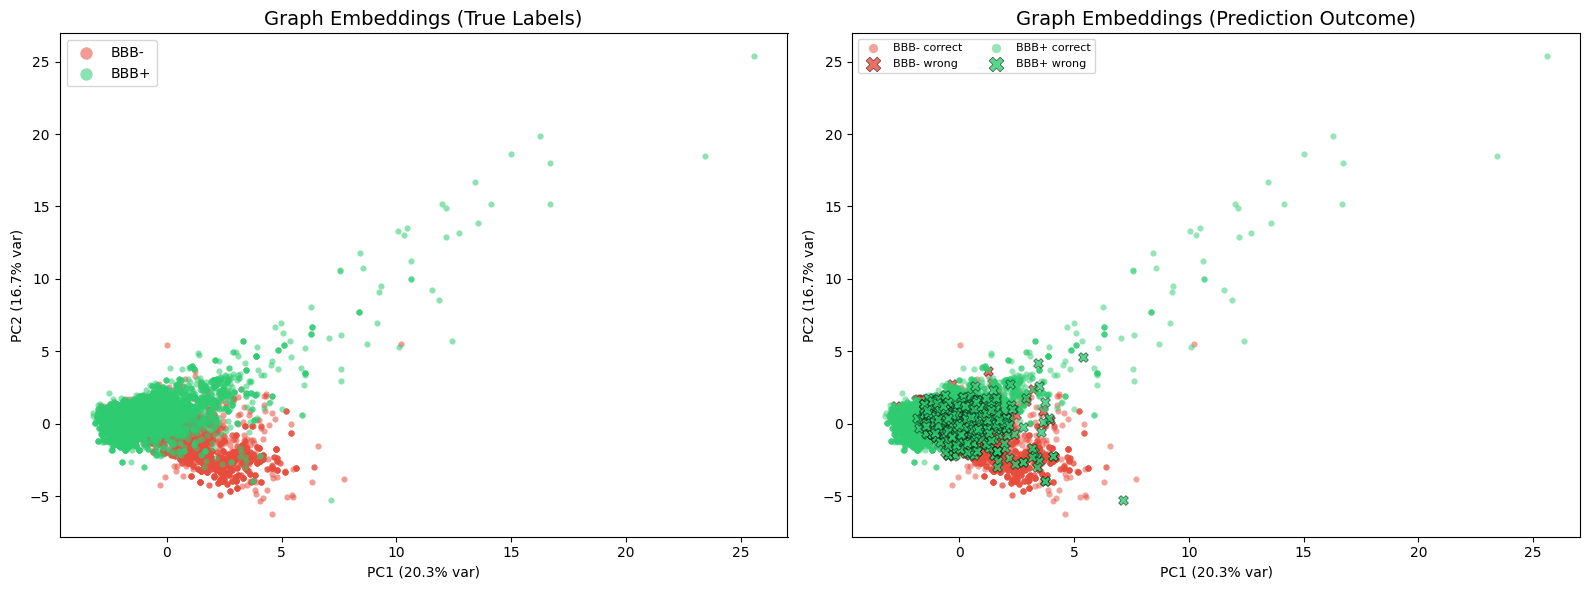

In [ ]:
@torch.no_grad()
def extract_embeddings(model, loader, device):
    """Return graph embeddings, true labels and predicted labels."""
    model.eval()
    all_embs, all_labels, all_preds = [], [], []
    for batch in loader:
        batch = batch.to(device)
        logits, emb = model(batch.x, batch.edge_index, batch.batch)
        all_embs.append(emb.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
    return np.vstack(all_embs), np.array(all_labels), np.array(all_preds)


# move graphs to cpu
for g in graphs_run:
    for attr in ['x', 'edge_index', 'edge_attr', 'y']:
        if hasattr(g, attr):
            v = getattr(g, attr)
            if torch.is_tensor(v):
                setattr(g, attr, v.cpu())
all_loader = DataLoader(graphs_run, batch_size=64, shuffle=False)
model.to(DEVICE)
embs, lbls, preds = extract_embeddings(model, all_loader, DEVICE)

# PCA 
pca       = PCA(n_components=2, random_state=SEED)
embs_2d   = pca.fit_transform(embs)
var_ratio = pca.explained_variance_ratio_

print(f"PCA explained variance: PC1 = {var_ratio[0]:.2%}, PC2 = {var_ratio[1]:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


class_names  = {0: "BBB-", 1: "BBB+"}
class_colors = {0: "red", 1: "green"}

for cls in [0, 1]:
    mask = lbls == cls
    axes[0].scatter(
        embs_2d[mask, 0], embs_2d[mask, 1],
        c=class_colors[cls], label=class_names[cls],
        alpha=0.55, s=20, linewidths=0,
    )
axes[0].set_title("Graph Embeddings (True Labels)", fontsize=14)
axes[0].set_xlabel(f"PC1 ({var_ratio[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({var_ratio[1]:.1%} var)")
axes[0].legend(markerscale=2)

correct   = preds == lbls
for cls in [0, 1]:
    mask_c = (lbls == cls) &  correct
    mask_w = (lbls == cls) & ~correct
    axes[1].scatter(
        embs_2d[mask_c, 0], embs_2d[mask_c, 1],
        c=class_colors[cls], marker="o", alpha=0.5, s=20, linewidths=0,
        label=f"{class_names[cls]} correct",
    )
    axes[1].scatter(
        embs_2d[mask_w, 0], embs_2d[mask_w, 1],
        c=class_colors[cls], marker="X", alpha=0.8, s=50, edgecolors="black",
        linewidths=0.4, label=f"{class_names[cls]} wrong",
    )
axes[1].set_title("Graph Embeddings (Prediction Outcome)", fontsize=14)
axes[1].set_xlabel(f"PC1 ({var_ratio[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({var_ratio[1]:.1%} var)")
axes[1].legend(markerscale=1.5, fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join("..", "figures", "gcn_pca_embeddings.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## Summary

| Step | Key design choice |
|---|---|
| **Features** | 29-dim atom features (element, degree, charge, H, hybridisation, aromaticity, ring) + optional 14-dim bond features |
| **Model** | Multi-layer GCN with BatchNorm, ReLU, Dropout --> configurable readout (mean/max/sum) --> 2-layer MLP classifier |
| **Loss** | Class-weighted cross-entropy to handle BBB+ / BBB− imbalance |
| **Sweep** | Bayesian WandB sweep over 7 hyperparameters; metric = val AUC-ROC |
| **Interpretability** | GNNExplainer (edge + node masks) and vanilla gradient saliency |
| **Visualisation** | PCA of graph-level read-out embeddings, coloured by class |

